# Data Review: Imputed Nodes Analysis
Comprehensive analysis and comparison of:
- **nodes.csv**: Original node data (baseline)
- **nodes_with_tomtom_data_imputed.csv**: Imputed dataset with urban features and ADT

This notebook examines the structure, quality, imputation status, and characteristics of both datasets.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set up plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load the datasets
data_dir = Path('../data/processed')
nodes_original = pd.read_csv(data_dir / 'nodes.csv')
nodes_traffic = pd.read_csv(data_dir / 'nodes_with_tomtom_data_imputed.csv')

print("Datasets loaded successfully!")
print(f"Original nodes shape: {nodes_original.shape}")
print(f"Imputed nodes shape: {nodes_traffic.shape}")
print(f"\nImputed dataset columns: {list(nodes_traffic.columns)}")

Datasets loaded successfully!
Original nodes shape: (9896, 6)
Imputed nodes shape: (4944, 8)

Imputed dataset columns: ['base_osmid', 'lat', 'lon', 'bc', 'bldg_density', 'traffic_index', 'is_observed', 'ADT_prop']


## 1. Dataset Structure Overview

In [28]:
# Display column information
print("=" * 80)
print("ORIGINAL NODES DATASET")
print("=" * 80)
print(f"\nShape: {nodes_original.shape}")
print(f"\nColumns: {list(nodes_original.columns)}")
print(f"\nData types:\n{nodes_original.dtypes}")
print(f"\nFirst 5 rows:")
print(nodes_original.head())
print(f"\nMemory usage: {nodes_original.memory_usage(deep=True).sum() / 1024:.2f} KB")

print("\n" + "=" * 80)
print("IMPUTED NODES DATASET")
print("=" * 80)
print(f"\nShape: {nodes_traffic.shape}")
print(f"\nColumns: {list(nodes_traffic.columns)}")
print(f"\nData types:\n{nodes_traffic.dtypes}")
print(f"\nFirst 5 rows:")
print(nodes_traffic.head())
print(f"\nMemory usage: {nodes_traffic.memory_usage(deep=True).sum() / 1024:.2f} KB")

# Identify new columns
new_columns = set(nodes_traffic.columns) - set(nodes_original.columns)
print("\n" + "=" * 80)
print(f"NEW COLUMNS IN IMPUTED DATA: {sorted(new_columns)}")
print("=" * 80)

ORIGINAL NODES DATASET

Shape: (9896, 6)

Columns: ['idx', 'base_osmid', 'layer', 'lat', 'lon', 'node_type']

Data types:
idx             int64
base_osmid      int64
layer           int64
lat           float64
lon           float64
node_type         str
dtype: object

First 5 rows:
   idx  base_osmid  layer       lat         lon     node_type
0    0           0      0  8.183123  124.257439  intersection
1    1           0      2  8.183123  124.257439  intersection
2    2           1      0  8.183337  124.257371  intersection
3    3           1      2  8.183337  124.257371  intersection
4    4           2      0  8.182834  124.257506  intersection

Memory usage: 1053.45 KB

IMPUTED NODES DATASET

Shape: (4944, 8)

Columns: ['base_osmid', 'lat', 'lon', 'bc', 'bldg_density', 'traffic_index', 'is_observed', 'ADT_prop']

Data types:
base_osmid         int64
lat              float64
lon              float64
bc               float64
bldg_density       int64
traffic_index    float64
is_observe

## 2. Data Quality & Completeness

In [29]:
# Missing values and completeness analysis
print("=" * 80)
print("MISSING VALUES ANALYSIS")
print("=" * 80)

print("\nOriginal Nodes - Missing Values:")
missing_orig = nodes_original.isnull().sum()
if missing_orig.sum() > 0:
    print(missing_orig[missing_orig > 0])
else:
    print("No missing values!")

print(f"\nImputed Nodes - Missing Values:")
missing_traffic = nodes_traffic.isnull().sum()
if missing_traffic.sum() > 0:
    print(missing_traffic[missing_traffic > 0])
    print(f"\nMissing value percentages:")
    print((missing_traffic[missing_traffic > 0] / len(nodes_traffic) * 100).round(2))
else:
    print("No missing values! (Complete imputation achieved ✓)")

# Duplicates analysis
print("\n" + "=" * 80)
print("DUPLICATE RECORDS")
print("=" * 80)
print(f"Original nodes duplicates: {nodes_original.duplicated().sum()}")
print(f"Imputed nodes duplicates: {nodes_traffic.duplicated().sum()}")

# Check for unique base_osmids
print("\n" + "=" * 80)
print("UNIQUE IDENTIFIERS")
print("=" * 80)
print(f"Original nodes unique base_osmid values: {nodes_original['base_osmid'].nunique()}")
print(f"Imputed nodes unique base_osmid values: {nodes_traffic['base_osmid'].nunique()}")
print(f"Imputed nodes total records: {len(nodes_traffic)}")
print(f"Records per unique node: {len(nodes_traffic) / nodes_traffic['base_osmid'].nunique():.1f}")

MISSING VALUES ANALYSIS

Original Nodes - Missing Values:
No missing values!

Imputed Nodes - Missing Values:
No missing values! (Complete imputation achieved ✓)

DUPLICATE RECORDS
Original nodes duplicates: 0
Imputed nodes duplicates: 0

UNIQUE IDENTIFIERS
Original nodes unique base_osmid values: 4944
Imputed nodes unique base_osmid values: 4944
Imputed nodes total records: 4944
Records per unique node: 1.0


## 3. Imputed Features Statistics

In [30]:
# Analyze imputed dataset features
imputed_cols = ['bc', 'bldg_density', 'traffic_index', 'ADT_prop']

print("=" * 80)
print("IMPUTED FEATURES SUMMARY STATISTICS")
print("=" * 80)
print(nodes_traffic[imputed_cols].describe().round(3))

# Imputation status analysis
print("\n" + "=" * 80)
print("IMPUTATION STATUS")
print("=" * 80)
observed_count = nodes_traffic['is_observed'].sum()
total_count = len(nodes_traffic)
imputed_count = total_count - observed_count

print(f"\nTotal nodes: {total_count}")
print(f"Observed (actual data): {observed_count} ({observed_count/total_count*100:.1f}%)")
print(f"Imputed (modeled): {imputed_count} ({imputed_count/total_count*100:.1f}%)")

# Compare observed vs imputed distributions
print("\n" + "=" * 80)
print("COMPARISON: Observed vs Imputed")
print("=" * 80)
observed_data = nodes_traffic[nodes_traffic['is_observed'] == True]
imputed_data = nodes_traffic[nodes_traffic['is_observed'] == False]

for col in imputed_cols:
    print(f"\n{col}:")
    print(f"  Observed - Mean: {observed_data[col].mean():.3f}, Median: {observed_data[col].median():.3f}")
    if len(imputed_data) > 0:
        print(f"  Imputed  - Mean: {imputed_data[col].mean():.3f}, Median: {imputed_data[col].median():.3f}")
    else:
        print(f"  Imputed  - N/A (no imputed records)")

# ADT analysis
print("\n" + "=" * 80)
print("ADT (Annual Daily Traffic) ANALYSIS")
print("=" * 80)
print(f"ADT Proportional Distribution:")
print(f"  Min: {nodes_traffic['ADT_prop'].min():.1f}")
print(f"  Max: {nodes_traffic['ADT_prop'].max():.1f}")
print(f"  Mean: {nodes_traffic['ADT_prop'].mean():.1f}")
print(f"  Median: {nodes_traffic['ADT_prop'].median():.1f}")

IMPUTED FEATURES SUMMARY STATISTICS
             bc  bldg_density  traffic_index  ADT_prop
count  4944.000        4944.0       4944.000  4944.000
mean      0.027           0.0          0.871   871.276
std       0.065           0.0          0.509   508.656
min       0.000           0.0          0.501   500.683
25%       0.001           0.0          0.618   617.619
50%       0.002           0.0          0.668   668.094
75%       0.014           0.0          0.944   944.253
max       0.452           0.0          3.288  3287.923

IMPUTATION STATUS

Total nodes: 4944
Observed (actual data): 516 (10.4%)
Imputed (modeled): 4428 (89.6%)

COMPARISON: Observed vs Imputed

bc:
  Observed - Mean: 0.058, Median: 0.024
  Imputed  - Mean: 0.023, Median: 0.002

bldg_density:
  Observed - Mean: 0.000, Median: 0.000
  Imputed  - Mean: 0.000, Median: 0.000

traffic_index:
  Observed - Mean: 1.164, Median: 1.056
  Imputed  - Mean: 0.837, Median: 0.649

ADT_prop:
  Observed - Mean: 1163.884, Median: 1055.6

## 4. Feature Correlations & Relationships

In [31]:
# Correlation analysis
print("=" * 80)
print("FEATURE CORRELATIONS")
print("=" * 80)

corr_cols = ['bc', 'bldg_density', 'traffic_index', 'ADT_prop']
corr_matrix = nodes_traffic[corr_cols].corr()
print("\nCorrelation Matrix:")
print(corr_matrix.round(3))

# Data quality checks
print("\n" + "=" * 80)
print("DATA VALIDITY CHECKS")
print("=" * 80)

print(f"\nBlock Centroid (bc):")
print(f"  Negative values: {(nodes_traffic['bc'] < 0).sum()}")
print(f"  Zero values: {(nodes_traffic['bc'] == 0).sum()}")

print(f"\nBuilding Density (bldg_density):")
print(f"  Negative values: {(nodes_traffic['bldg_density'] < 0).sum()}")
print(f"  Zero values: {(nodes_traffic['bldg_density'] == 0).sum()}")
print(f"  Zero percentage: {(nodes_traffic['bldg_density'] == 0).sum() / len(nodes_traffic) * 100:.1f}%")

print(f"\nTraffic Index:")
print(f"  Unique values: {nodes_traffic['traffic_index'].nunique()}")
print(f"  Value range: {nodes_traffic['traffic_index'].min():.3f} to {nodes_traffic['traffic_index'].max():.3f}")

print(f"\nADT Proportional (ADT_prop):")
print(f"  Negative values: {(nodes_traffic['ADT_prop'] < 0).sum()}")
print(f"  Zero values: {(nodes_traffic['ADT_prop'] == 0).sum()}")

FEATURE CORRELATIONS

Correlation Matrix:
                  bc  bldg_density  traffic_index  ADT_prop
bc             1.000           NaN          0.719     0.719
bldg_density     NaN           NaN            NaN       NaN
traffic_index  0.719           NaN          1.000     1.000
ADT_prop       0.719           NaN          1.000     1.000

DATA VALIDITY CHECKS

Block Centroid (bc):
  Negative values: 0
  Zero values: 618

Building Density (bldg_density):
  Negative values: 0
  Zero values: 4944
  Zero percentage: 100.0%

Traffic Index:
  Unique values: 4466
  Value range: 0.501 to 3.288

ADT Proportional (ADT_prop):
  Negative values: 0
  Zero values: 0


## 5. Distribution Visualizations

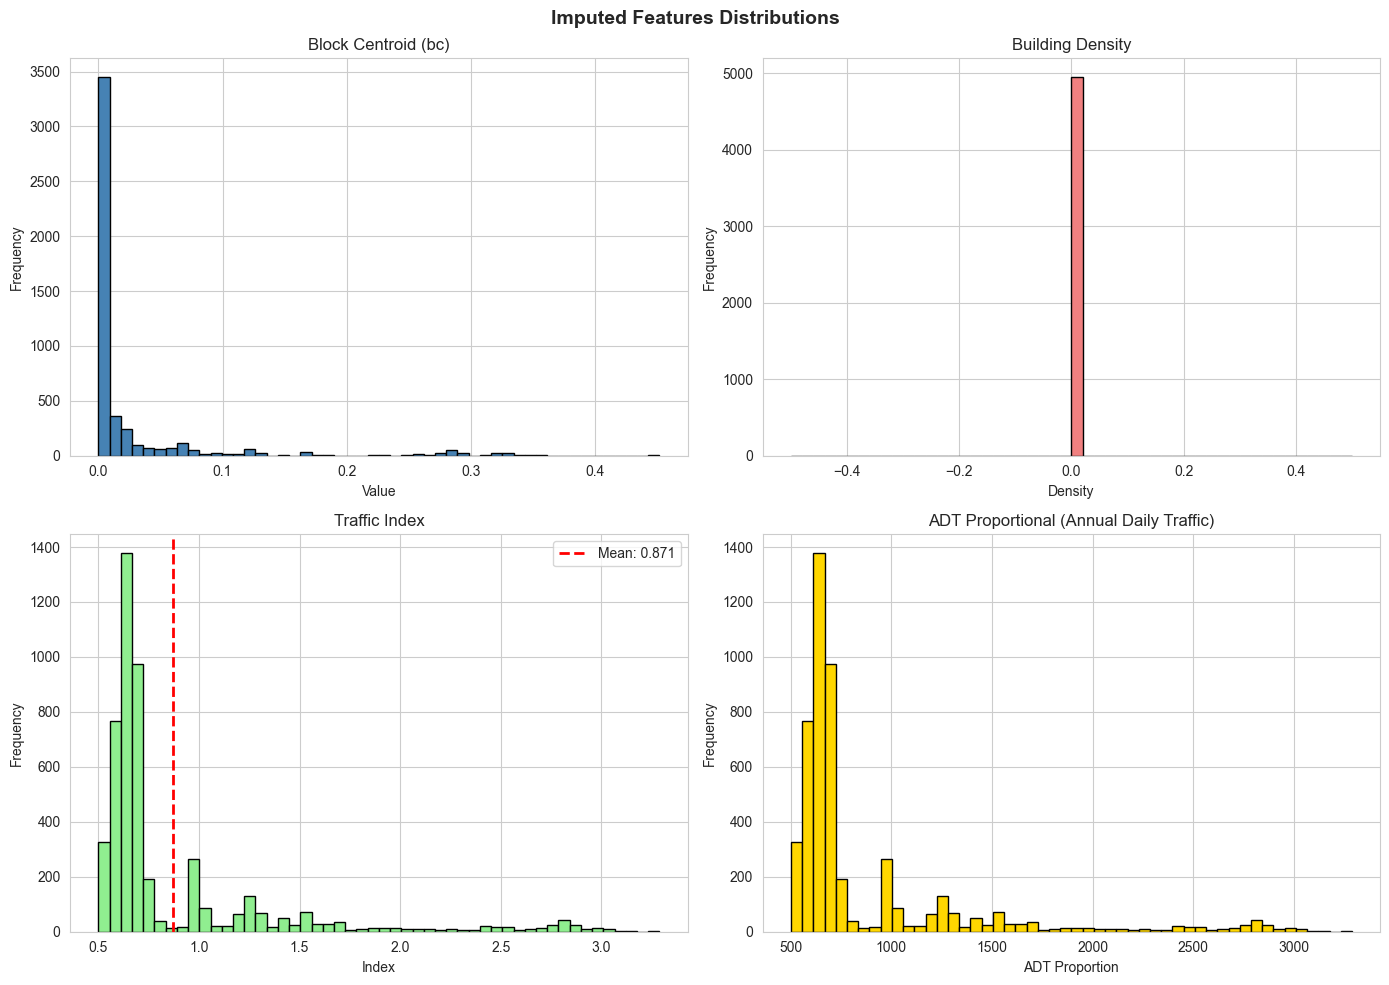

In [32]:
# Visualize feature distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Imputed Features Distributions', fontsize=14, fontweight='bold')

# Block Centroid
axes[0, 0].hist(nodes_traffic['bc'], bins=50, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Block Centroid (bc)')
axes[0, 0].set_xlabel('Value')
axes[0, 0].set_ylabel('Frequency')

# Building Density
axes[0, 1].hist(nodes_traffic['bldg_density'], bins=50, color='lightcoral', edgecolor='black')
axes[0, 1].set_title('Building Density')
axes[0, 1].set_xlabel('Density')
axes[0, 1].set_ylabel('Frequency')

# Traffic Index
axes[1, 0].hist(nodes_traffic['traffic_index'], bins=50, color='lightgreen', edgecolor='black')
axes[1, 0].set_title('Traffic Index')
axes[1, 0].set_xlabel('Index')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].axvline(nodes_traffic['traffic_index'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {nodes_traffic["traffic_index"].mean():.3f}')
axes[1, 0].legend()

# ADT Proportional
axes[1, 1].hist(nodes_traffic['ADT_prop'], bins=50, color='gold', edgecolor='black')
axes[1, 1].set_title('ADT Proportional (Annual Daily Traffic)')
axes[1, 1].set_xlabel('ADT Proportion')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

C:\Users\lifei\AppData\Local\Temp\ipykernel_11020\1018783088.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=labels)
C:\Users\lifei\AppData\Local\Temp\ipykernel_11020\1018783088.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=labels)
C:\Users\lifei\AppData\Local\Temp\ipykernel_11020\1018783088.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=labels)
C:\Users\lifei\AppData\Local\Temp\ipykernel_11020\1018783088.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels

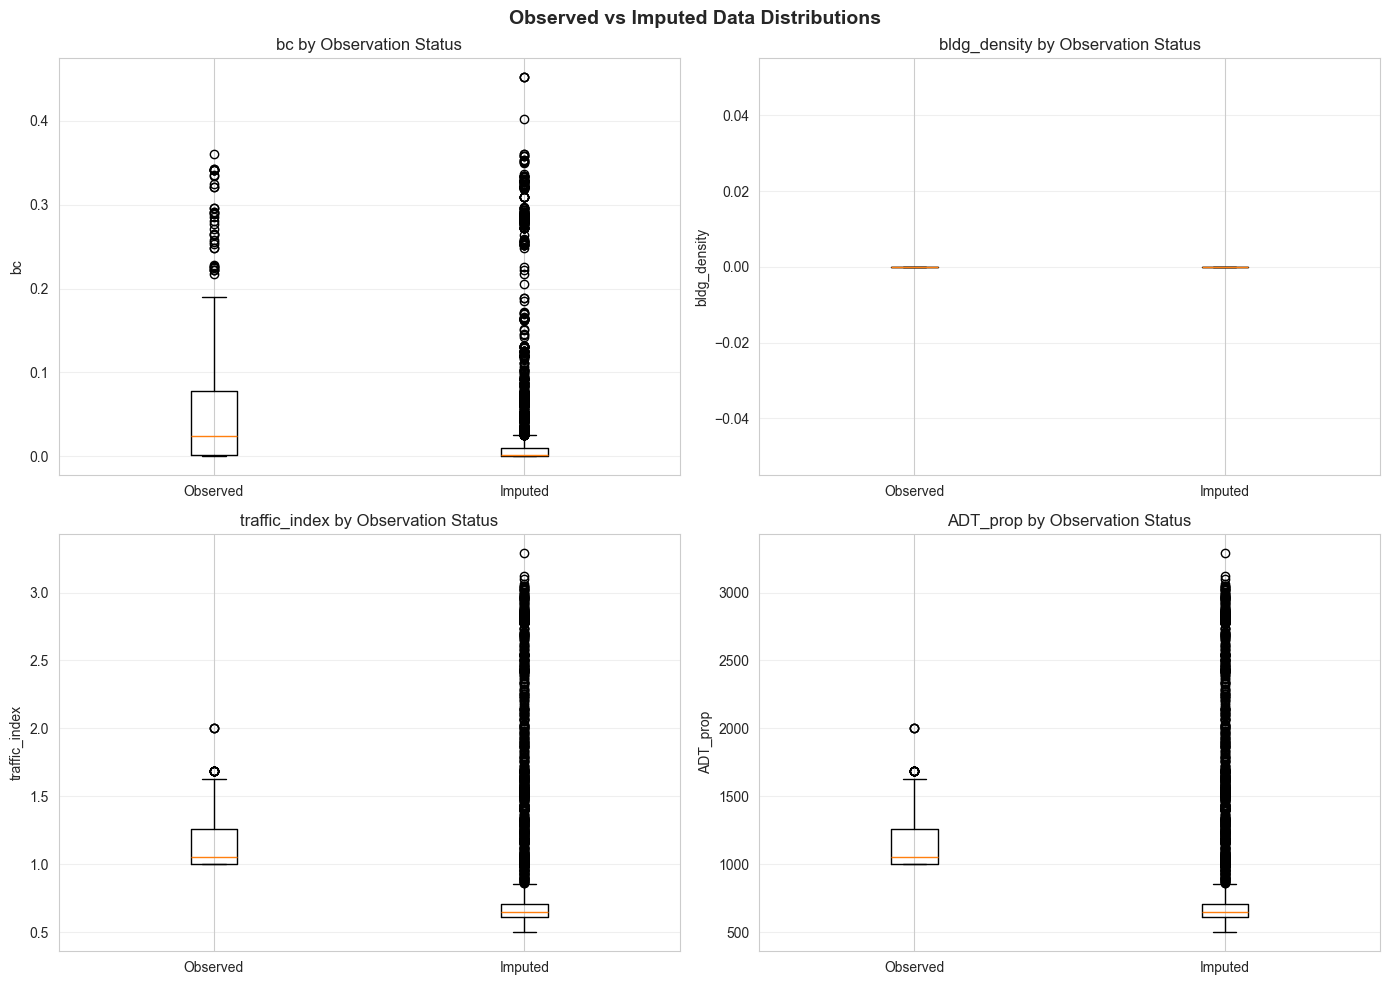

In [33]:
# Box plots: Observed vs Imputed
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Observed vs Imputed Data Distributions', fontsize=14, fontweight='bold')

observed = nodes_traffic[nodes_traffic['is_observed'] == True]
imputed = nodes_traffic[nodes_traffic['is_observed'] == False]

features = ['bc', 'bldg_density', 'traffic_index', 'ADT_prop']
for idx, feature in enumerate(features):
    ax = axes[idx // 2, idx % 2]
    data_to_plot = [observed[feature], imputed[feature]] if len(imputed) > 0 else [observed[feature]]
    labels = ['Observed', 'Imputed'] if len(imputed) > 0 else ['Observed']
    ax.boxplot(data_to_plot, labels=labels)
    ax.set_ylabel(feature)
    ax.grid(axis='y', alpha=0.3)
    ax.set_title(f'{feature} by Observation Status')

plt.tight_layout()
plt.show()

## 6. Spatial Analysis

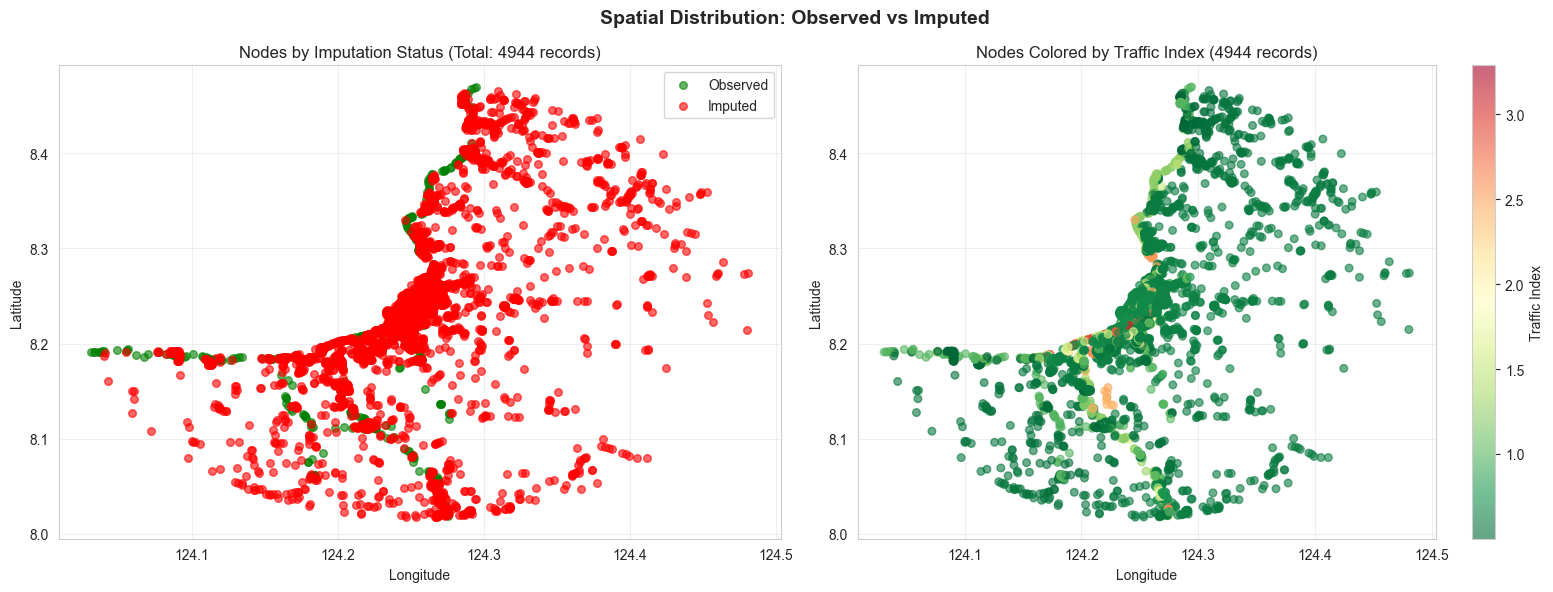

In [34]:
# Spatial distribution analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Spatial Distribution: Observed vs Imputed', fontsize=14, fontweight='bold')

observed = nodes_traffic[nodes_traffic['is_observed'] == True]
imputed = nodes_traffic[nodes_traffic['is_observed'] == False]

# Plot 1: Observation status
axes[0].scatter(observed['lon'], observed['lat'], alpha=0.6, s=30, color='green', label='Observed')
if len(imputed) > 0:
    axes[0].scatter(imputed['lon'], imputed['lat'], alpha=0.6, s=30, color='red', label='Imputed')
axes[0].set_title(f'Nodes by Imputation Status (Total: {len(nodes_traffic)} records)')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].grid(alpha=0.3)
axes[0].legend()

# Plot 2: Colored by traffic index
scatter = axes[1].scatter(nodes_traffic['lon'], nodes_traffic['lat'], c=nodes_traffic['traffic_index'], cmap='RdYlGn_r', alpha=0.6, s=30)
axes[1].set_title(f'Nodes Colored by Traffic Index ({len(nodes_traffic)} records)')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].grid(alpha=0.3)
cbar = plt.colorbar(scatter, ax=axes[1])
cbar.set_label('Traffic Index')

plt.tight_layout()
plt.show()

## 7. Comparative Analysis: Original vs Imputed

In [35]:
# Comparison analysis
print("=" * 80)
print("COMPARATIVE ANALYSIS: Original vs. Imputed")
print("=" * 80)

# Check node type distribution in original
print("\nNODE TYPES IN ORIGINAL DATASET:")
if 'node_type' in nodes_original.columns:
    print(nodes_original['node_type'].value_counts())
else:
    print("node_type column not found")

# Layer distribution
print("\nLAYER DISTRIBUTION IN ORIGINAL DATASET:")
if 'layer' in nodes_original.columns:
    print(nodes_original['layer'].value_counts().sort_index())
else:
    print("layer column not found")

# Geographic coverage
print("\n" + "=" * 80)
print("GEOGRAPHIC COVERAGE")
print("=" * 80)
print(f"\nOriginal nodes bounding box:")
print(f"  Latitude: {nodes_original['lat'].min():.6f} to {nodes_original['lat'].max():.6f}")
print(f"  Longitude: {nodes_original['lon'].min():.6f} to {nodes_original['lon'].max():.6f}")
print(f"\nImputed nodes bounding box:")
print(f"  Latitude: {nodes_traffic['lat'].min():.6f} to {nodes_traffic['lat'].max():.6f}")
print(f"  Longitude: {nodes_traffic['lon'].min():.6f} to {nodes_traffic['lon'].max():.6f}")

# Check OSM ID overlap
print("\n" + "=" * 80)
print("NODE COVERAGE & MAPPING")
print("=" * 80)
orig_osmids = set(nodes_original['base_osmid'].unique())
traffic_osmids = set(nodes_traffic['base_osmid'].unique())

print(f"Unique OSM IDs in original nodes: {len(orig_osmids)}")
print(f"Unique OSM IDs in imputed nodes: {len(traffic_osmids)}")
print(f"Overlap: {len(orig_osmids & traffic_osmids)}")
print(f"Coverage: {len(orig_osmids & traffic_osmids) / len(orig_osmids) * 100:.1f}%")

if len(orig_osmids - traffic_osmids) > 0:
    print(f"\nNodes NOT in imputed data: {len(orig_osmids - traffic_osmids)}")
if len(traffic_osmids - orig_osmids) > 0:
    print(f"Extra nodes in imputed data: {len(traffic_osmids - orig_osmids)}")

COMPARATIVE ANALYSIS: Original vs. Imputed

NODE TYPES IN ORIGINAL DATASET:
node_type
intersection    9888
stop               8
Name: count, dtype: int64

LAYER DISTRIBUTION IN ORIGINAL DATASET:
layer
0    4944
1       8
2    4944
Name: count, dtype: int64

GEOGRAPHIC COVERAGE

Original nodes bounding box:
  Latitude: 8.017620 to 8.469663
  Longitude: 124.031036 to 124.480827

Imputed nodes bounding box:
  Latitude: 8.017620 to 8.469663
  Longitude: 124.031036 to 124.480827

NODE COVERAGE & MAPPING
Unique OSM IDs in original nodes: 4944
Unique OSM IDs in imputed nodes: 4944
Overlap: 4944
Coverage: 100.0%


## 8. Summary & Key Findings

In [36]:
# Generate summary
print("=" * 80)
print("SUMMARY & KEY FINDINGS")
print("=" * 80)

total_records = len(nodes_traffic)
observed_pct = (observed_count / total_records * 100)
imputed_pct = (imputed_count / total_records * 100)

summary = f"""
DATASET OVERVIEW:
  • Original baseline nodes: {len(nodes_original):,} records
  • Imputed extended dataset: {total_records:,} records
  • Coverage: {len(orig_osmids & traffic_osmids) / len(orig_osmids) * 100:.1f}% of original nodes mapped

IMPUTATION STATUS:
  • Observed (ground truth): {observed_count:,} ({observed_pct:.1f}%)
  • Imputed (modeled): {imputed_count:,} ({imputed_pct:.1f}%)
  • No missing values in final dataset ✓

KEY FEATURES SUMMARY:
  Block Centroid (bc):
    • Mean: {nodes_traffic['bc'].mean():.3f}
    • Range: {nodes_traffic['bc'].min():.3f} to {nodes_traffic['bc'].max():.3f}
  
  Building Density:
    • Mean: {nodes_traffic['bldg_density'].mean():.3f}
    • Range: {nodes_traffic['bldg_density'].min():.3f} to {nodes_traffic['bldg_density'].max():.3f}
  
  Traffic Index:
    • Mean: {nodes_traffic['traffic_index'].mean():.3f}
    • Range: {nodes_traffic['traffic_index'].min():.3f} to {nodes_traffic['traffic_index'].max():.3f}
  
  ADT Proportional:
    • Mean: {nodes_traffic['ADT_prop'].mean():.1f}
    • Range: {nodes_traffic['ADT_prop'].min():.1f} to {nodes_traffic['ADT_prop'].max():.1f}

GEOGRAPHIC COVERAGE:
  • Latitude range: {nodes_traffic['lat'].min():.6f} to {nodes_traffic['lat'].max():.6f}
  • Longitude range: {nodes_traffic['lon'].min():.6f} to {nodes_traffic['lon'].max():.6f}
  • Area: {nodes_traffic['lat'].max() - nodes_traffic['lat'].min():.4f}° latitude × {nodes_traffic['lon'].max() - nodes_traffic['lon'].min():.4f}° longitude

IMPUTATION QUALITY:
  • Observed and Imputed distributions should be similar (sign of good imputation)
  • Check feature correlations to validate relationships
  • Geographic distribution should be consistent across observed/imputed
"""

print(summary)

SUMMARY & KEY FINDINGS

DATASET OVERVIEW:
  • Original baseline nodes: 9,896 records
  • Imputed extended dataset: 4,944 records
  • Coverage: 100.0% of original nodes mapped

IMPUTATION STATUS:
  • Observed (ground truth): 516 (10.4%)
  • Imputed (modeled): 4,428 (89.6%)
  • No missing values in final dataset ✓

KEY FEATURES SUMMARY:
  Block Centroid (bc):
    • Mean: 0.027
    • Range: 0.000 to 0.452

  Building Density:
    • Mean: 0.000
    • Range: 0.000 to 0.000

  Traffic Index:
    • Mean: 0.871
    • Range: 0.501 to 3.288

  ADT Proportional:
    • Mean: 871.3
    • Range: 500.7 to 3287.9

GEOGRAPHIC COVERAGE:
  • Latitude range: 8.017620 to 8.469663
  • Longitude range: 124.031036 to 124.480827
  • Area: 0.4520° latitude × 0.4498° longitude

IMPUTATION QUALITY:
  • Observed and Imputed distributions should be similar (sign of good imputation)
  • Check feature correlations to validate relationships
  • Geographic distribution should be consistent across observed/imputed



In [ ]:
# Create interactive folium map with ADT_prop visualization
import folium
from branca.colormap import LinearColormap

# Prepare data for mapping
plot_df = nodes_traffic.copy().drop_duplicates(subset="base_osmid").dropna(subset=["ADT_prop"])

# Map center
center = [plot_df["lat"].mean(), plot_df["lon"].mean()]
m = folium.Map(location=center, zoom_start=13, tiles="CartoDB DarkMatter")

# Create color map based on ADT_prop
cmap = LinearColormap(
    ["#2166ac", "#92c5de", "#f4a582", "#d6604d", "#b2182b"],
    vmin=plot_df["ADT_prop"].quantile(0.05),
    vmax=plot_df["ADT_prop"].quantile(0.95),
    caption="ADT_prop (Annual Daily Traffic Proportion)"
)
cmap.add_to(m)

# Add markers: observed nodes larger, imputed nodes smaller
for _, row in plot_df.iterrows():
    color = cmap(row["ADT_prop"])
    is_obs = row["is_observed"]
    
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=5 if is_obs else 3,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.85 if is_obs else 0.55,
        weight=2 if is_obs else 1,
        popup=folium.Popup(
            f"<b>Node {row['base_osmid']}</b><br>"
            f"ADT_prop: {row['ADT_prop']:.0f}<br>"
            f"Traffic Index: {row['traffic_index']:.3f}<br>"
            f"BC: {row['bc']:.4f}<br>"
            f"Building Density: {row['bldg_density']:.0f}<br>"
            f"Status: {'● Observed' if is_obs else '○ Imputed'}",
            max_width=300
        ),
        tooltip=(
            f"ADT: {row['ADT_prop']:.0f} | "
            f"{'Observed' if is_obs else 'Imputed'}"
        ),
    ).add_to(m)

# Save map
from pathlib import Path
results_dir = Path("../results")
results_dir.mkdir(parents=True, exist_ok=True)
map_path = results_dir / "data_review_traffic_map.html"
m.save(str(map_path))

print(f"✓ Interactive map saved to: {map_path}")
print(f"  Total nodes mapped: {len(plot_df)}")
print(f"  Observed: {plot_df['is_observed'].sum()}")
print(f"  Imputed: {(~plot_df['is_observed']).sum()}")
print(f"\nOpen the HTML file in a web browser to explore the map interactively.")

# Display the map
m


## 9. Interactive Map Visualization